In [14]:
def oracle(qc, n):
    for i in range(n-1):
        qc.cx(i, n+i)
        qc.cx(i+1, n+i)
        qc.x(n+1)

    temp_result = list(range(n, 2*n - 1))
    ancilla = 2*n - 1
    qc.mcx(temp_result, ancilla)

    for i in reversed(range(n-1)):
        qc.x(n+1)
        qc.cx(i+1, n+1)
        qc.cx(i, n+1)

    return qc

In [15]:
def diffuser(qc, n):
    qc.h(range(n))
    qc.x(range(n))

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    qc.x(range(n))
    qc.h(range(n))

    return qc

In [16]:
from qiskit import QuantumCircuit

def grover(n):
    total_qubits = 2*n
    qc = QuantumCircuit(total_qubits, n)

    qc.h(range(n))
    qc.x(total_qubits - 1)
    qc.h(total_qubits - 1)
    qc.barrier()

    steps = 18
    for _ in range(steps):
        oracle(qc, n)
        qc.barrier()
        diffuser(qc, n) 
        qc.barrier()

    qc.measure(range(n), range(n))
    return qc

n = 10
grover_circuit = grover(n)
grover_circuit.draw(output='mpl')

Results: {'1001110101': 1, '1001101111': 1, '0111100111': 1, '1111001110': 1, '0000110100': 1, '1010100111': 1, '1100110001': 1, '1111110101': 1, '0110100010': 1, '0001001111': 1, '0100001010': 1, '0101111000': 2, '1010100001': 1, '1101111011': 1, '1000011100': 1, '1101000000': 1, '1010000010': 1, '1101101110': 1, '0011010111': 2, '1111100010': 1, '1011110111': 2, '1010001110': 1, '0000110000': 2, '1001110110': 1, '1100111001': 1, '0111111011': 1, '0111111000': 1, '0111110010': 1, '0100101001': 1, '1101110110': 2, '1011011101': 1, '0111110100': 1, '1111101101': 1, '0110100101': 1, '0011000000': 1, '1000100001': 1, '0010010110': 1, '0111001000': 1, '1010010000': 1, '1011100111': 1, '0111010111': 1, '0101110010': 1, '1101001111': 1, '1101001001': 2, '1101001000': 1, '0001100000': 1, '1000110011': 1, '0011010100': 1, '1110111111': 1, '1101110100': 1, '1101100101': 4, '1011111100': 1, '1001111011': 1, '1111000001': 1, '0110011111': 1, '0011010110': 1, '0011010101': 2, '0110011001': 2, '010

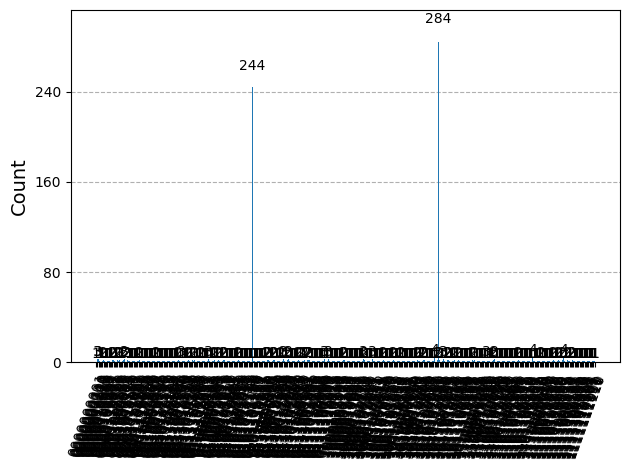

In [17]:
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

backend = Aer.get_backend('qasm_simulator')
result = backend.run((transpile(grover_circuit, backend)), shots=1024).result()
counts = result.get_counts()

print(f"Results: {counts}")
display(plot_histogram(counts))